# B3 · Transformer Attention Mechanism

Scaled dot-product attention from scratch (topic **B3** of the project catalog):
profile a CPU transformer block, find the bottleneck, and replace it — only it —
with progressively better CUDA kernels.

| Version | Attention implementation | Key idea |
|---|---|---|
| `TorchPipeline` | torch matmul + softmax | all-PyTorch profiling reference: every stage on the same vectorized footing |
| `CpuPipeline` | bare Python triple loops | sequential timing baseline; its O(N²) cost caps the sweep at N = 2048 |
| `GpuV1` | three naive numba kernels | one thread per output element, everything through global memory |
| `GpuV2` | tiled QK$^T$ + online softmax | shared-memory tiles + one-pass softmax: reuse over redundancy |

Everything except attention — embedding, projections, norms, FFN — stays in
PyTorch on the CPU (*partial GPU principle*): only the profiled bottleneck moves.

In [1]:
# On Colab: clone the repo, then `pip install numba` if missing.
import sys
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline, TorchPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
# from gpu_v3 import GpuV3
import bench

print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()}")

torch 2.12.1+cu130 | CUDA available: True


## Stage 1 — CPU baseline and bottleneck analysis

Two CPU models split the two Stage-1 jobs.

**Profiling — `TorchPipeline`.** For the step-time distribution every stage,
attention included, runs as vectorized PyTorch ops, so the
`torch.profiler.record_function` shares reflect *algorithmic* cost, not
interpreter overhead. Attention is the only $O(N^2 D)$ step in the block;
projections and FFN are $O(N D^2)$, linear in N. Chart 1 shows exactly that
scaling: the attention share starts small at $N = 64$, where the FFN
dominates, and grows with N until it owns the forward pass (by FLOP count the
crossover sits around $N \approx 5.5D \approx 2800$). The step that scales
worst is the GPU target.

**Timing baseline — `CpuPipeline`.** The speedup sweep needs a sequential
reference, so there attention runs as bare Python triple loops — no BLAS, no
SIMD, no threads — while every other step stays in PyTorch. Its $O(N^2 D)$
interpreter cost (~8 min per attention pass at $N = 2048$) is what caps the
benchmark sweep at $N = 2048$ — just below the crossover; the profile above
is what says the GPU's advantage only grows from there.

In [2]:
# Correctness gate: both CPU models must match torch's SDPA before they can
# serve as profiling / timing references.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    for m in (cpu_model, TorchPipeline().eval()):
        # CpuPipeline: fp64 python floats vs fp32; TorchPipeline: unfused vs fused SDPA
        torch.testing.assert_close(m(x), bench.sdpa_reference(m, x),
                                   atol=1e-4, rtol=1e-3)
print("CpuPipeline & TorchPipeline match torch.nn.functional.scaled_dot_product_attention")

CpuPipeline & TorchPipeline match torch.nn.functional.scaled_dot_product_attention


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-07-23 17:57:55 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:57:55 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:57:55 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:57:55 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:57:56 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:57:56 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:57:56 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:57:56 2957158:2957158 ActivityProfilerController.cpp:455] profiler_st

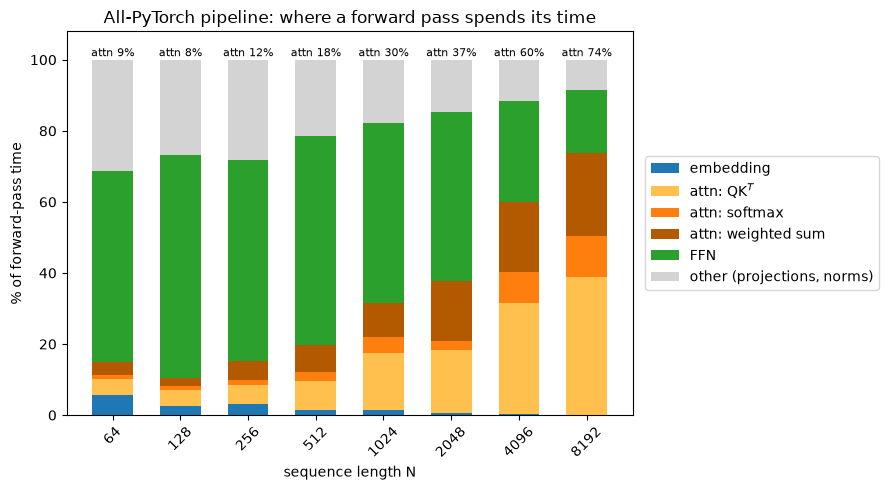

In [3]:
# Chart 1 -- share of forward-pass time per step (all-PyTorch pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 14)]
torch_model = TorchPipeline().eval()
pcts = [bench.step_percentages(torch_model, n) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("All-PyTorch pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

Two versions, one lesson each: V1 is the straight port — correct, massively
parallel, and wasteful with memory traffic; V2 shows where kernel speed
actually lives: data reuse.

**V1 — naive three-kernel** (`gpu_v1.py`): `_matmul` (QK$^T$), `_scale`,
`_softmax`, `_matmul` (weights·V) — four launches, and every intermediate
including the full N×N score matrix round-trips through global memory.
The matmul loads are coalesced (adjacent threads read adjacent addresses) but
nothing is reused, and the softmax uses one block per row with a coalesced
read but still passes over the row three times (max, sum, write); V2 folds
those into one pass.

**V2 — tiled QK$^T$ + online softmax** (`gpu_v2.py`): `_qkt_tiled` stages
16×16 tiles of Q and K in shared memory (each element is fetched from global
memory 16× less often; shared arrays are padded to dodge bank conflicts) and fuses
the $1/\sqrt{D}$ scaling into the epilogue. `_softmax_online` uses one block
per row: a running (max, sum) pair rescaled when the max moves — the
log-sum-exp trick — gets both out of **one** coalesced read of the row.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [4]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2):  # , GpuV3
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV1: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV2: matches torch SDPA within 1e-4


### Distribution shift — the bottleneck moves back

Same buckets for all three pipelines: attention as a single step, since the
GPU versions don't split it into sub-steps (and their attention time includes
the CPU↔GPU transfers — the honest cost of the swap); the all-PyTorch panel
reuses Chart 1's measurements. Moving attention to the GPU flips Chart 1: the
$O(N^2)$ step drops out of the distribution and the forward pass belongs to
the linear PyTorch steps again — until the $O(N^2)$ kernel time starts
creeping back in at the top of the sweep, the same scaling argument one level
down. V1 vs V2 changes only the attention band, so the faster kernel is
directly visible as a thinner orange stripe.

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
USDT:2026-07-23 17:58:02 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:58:02 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:58:02 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:58:02 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:58:02 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:58:02 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:

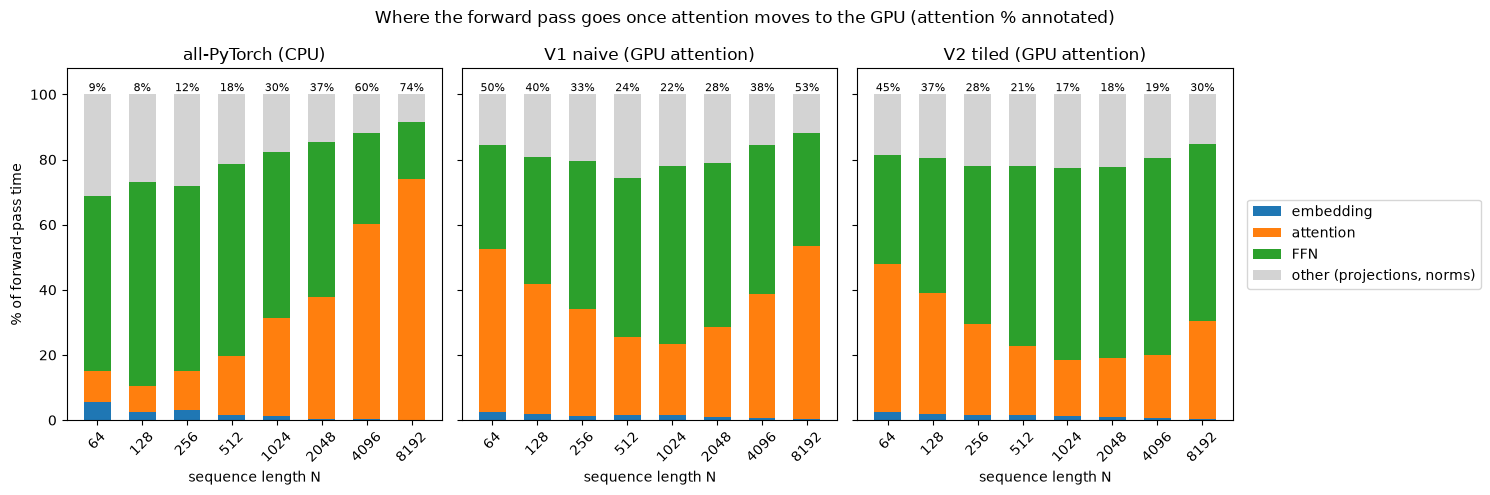

In [5]:
# Chart 1b -- step-time distribution per pipeline (coarse buckets, all comparable)
if cuda.is_available():
    # torch panel reuses Chart 1's profile: the sub-steps sum to the attention total
    dist = {"all-PyTorch (CPU)": [
        {"1_embedding": p["1_embedding"],
         "2_attention_total": sum(p[s] for s in bench.ATTN_STEPS),
         "3_ffn": p["3_ffn"], "other": p["other"]} for p in pcts]}
    for title, m in (("V1 naive (GPU attention)", GpuV1().eval()),
                     ("V2 tiled (GPU attention)", GpuV2().eval())):
        dist[title] = [bench.step_percentages(m, n, steps=bench.STEPS_TOTAL)
                       for n in PROFILE_LENS]
    torch.cuda.empty_cache()  # drop the dead N x N blocks the GPU passes leave cached

    parts = bench.STEPS_TOTAL + ["other"]
    names = {"1_embedding": "embedding", "2_attention_total": "attention",
             "3_ffn": "FFN", "other": "other (projections, norms)"}
    colors = {"1_embedding": "tab:blue", "2_attention_total": "tab:orange",
              "3_ffn": "tab:green", "other": "lightgray"}

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    xpos = np.arange(len(PROFILE_LENS))
    for ax, (title, ps) in zip(axes, dist.items()):
        bottom = np.zeros(len(PROFILE_LENS))
        for part in parts:
            vals = np.array([p[part] for p in ps])
            ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
            bottom += vals
        for xi, p in zip(xpos, ps):  # annotate the attention share
            ax.text(xi, 101, f"{p['2_attention_total']:.0f}%", ha="center", fontsize=8)
        ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.set_ylim(0, 108)
    axes[0].set_ylabel("% of forward-pass time")
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.suptitle("Where the forward pass goes once attention moves to the GPU (attention % annotated)")
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the combined step-share chart")

## Benchmark — attention step time

Timings cover the attention step only, on precomputed q, k, v. The GPU
columns *include* the CPU→GPU→CPU transfers — the true cost of swapping a
kernel into an otherwise-CPU pipeline. N sweeps the powers of two from $2^6$
to $2^{11}$ (64 → 2048), covering every spec checkpoint (128 / 512 / 2048).
The CPU column is one profiled pass per point, which yields the three
sub-step times — QK$^T$, softmax, weighted sum, reused as the per-step
baselines in Chart 3 — and their sum, the attention total (~11 min for the
column; that O(N²) cost is what caps the sweep).

In [6]:
SEQ_LENS = [2 ** x for x in range(6, 12)]

if cuda.is_available():
    classes = {"V1 naive": GpuV1,
               "V2 tiled + online softmax": GpuV2,
               # "V3 flash fused": GpuV3,
               }
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    times["torch SDPA (GPU)"] = [bench.sdpa_gpu_ms(cpu_model, n, reps=3) for n in SEQ_LENS]
    torch.cuda.empty_cache()  # drop cached blocks so the sweep leaves no footprint

    # CPU measured last (slowest by far): one profiled pass per point yields the
    # per-step times (for Chart 3) and their sum, the CPU column (~11 min total)
    cpu_steps = [bench.attention_step_ms(cpu_model, n) for n in SEQ_LENS]
    times = {"CPU": [sum(d.values()) for d in cpu_steps], **times}

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"CPU": "tab:red",
          "V1 naive": "tab:blue", "V2 tiled + online softmax": "tab:orange",
          "V3 flash fused": "tab:green", "torch SDPA (GPU)": "gray"}

USDT:2026-07-23 17:58:07 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:58:07 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:58:07 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:58:08 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:58:08 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:58:13 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:58:13 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 17:58:38 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 17:58:38 2957158:2957158 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-07-23 18:00:31 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-07-23 18:00:31 2957158:2957158 ActivityProfilerController.cpp:415] profiler

     N                          CPU                    V1 naive   V2 tiled + online softmax            torch SDPA (GPU)
-----------------------------------------------------------------------------------------------------------------------
    64                    278.70 ms                     2.58 ms                     1.96 ms                     0.63 ms
   128                   1110.87 ms                     2.40 ms                     2.10 ms                     0.72 ms
   256                   4828.91 ms                     2.83 ms                     2.50 ms                     1.03 ms
   512                  24346.06 ms                     3.80 ms                     3.23 ms                     1.64 ms
  1024                 112697.69 ms                     7.07 ms                     4.81 ms                     2.54 ms
  2048                 463557.30 ms                    20.02 ms                    10.67 ms                     4.85 ms


USDT:2026-07-23 18:08:15 2957158:2957158 ActivityProfilerController.cpp:455] profiler_stop


## Attention kernel timing — compute only

How fast are the kernels once the transfers are taken out of the picture?
Following the HW02 methodology: **device-resident timing with CUDA events**, so
the timed region is pure compute — no CPU→GPU→CPU copy. This isolates kernel
speed from the pipeline-boundary tax that the end-to-end sweep pays, and feeds
the transfer-share analysis below (Chart 2).

In [7]:
# Kernel-only timing sweep (CUDA events, device-resident)
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs")

    kmodels = {"V1 naive": GpuV1().eval(),
               "V2 tiled + online softmax": GpuV2().eval(),
               # "V3 flash fused": GpuV3().eval(),
               }
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=10) for n in SEQ_LENS]
              for name, m in kmodels.items()}
    ktimes["torch SDPA (GPU)"] = [bench.sdpa_kernel_ms(cpu_model, n, reps=10)
                                  for n in SEQ_LENS]
    # per-step kernel times (QK^T, softmax, weighted sum) for Chart 3 --
    # only the unfused versions expose the three step methods (V3 is one kernel)
    ksteps = {name: [bench.attention_kernel_step_ms(m, n, reps=10) for n in SEQ_LENS]
              for name, m in kmodels.items() if "_step_qkt" in type(m).__dict__}
    torch.cuda.empty_cache()  # drop the dead N x N blocks V1/V2 leave cached

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: NVIDIA L4 | 58 SMs

     N                      V1 naive     V2 tiled + online softmax              torch SDPA (GPU)   (kernel-only ms)
------------------------------------------------------------------------------------------------
    64                      1.654 ms                      1.376 ms                      0.215 ms
   128                      1.610 ms                      1.338 ms                      0.201 ms
   256                      1.612 ms                      1.352 ms                      0.196 ms
   512                      1.635 ms                      1.359 ms                      0.217 ms
  1024                      3.936 ms                      1.456 ms                      0.240 ms
  2048                     18.117 ms                      5.784 ms                      0.848 ms


### Transfer cost — compute-only vs with-transfer

The end-to-end benchmark pays the CPU→GPU→CPU copy on every call; the kernel
sweep does not. Their difference is the price of swapping a GPU kernel into a
CPU pipeline: the copy grows O(N) while compute grows O(N²), so the share falls
once compute outgrows the launch-and-copy floor — soonest for the slowest
kernel (V1, a few % by N = 2048), last for the fastest (torch SDPA, still
~80% overhead at the top of the sweep). Chart 2 traces exactly that.

In [8]:
if cuda.is_available():
    name = "V2 tiled + online softmax"
    print(f"{'N':>6} {'with transfer':>14} {'kernel only':>12} {'overhead':>10} {'share':>7}")
    for i, n in enumerate(SEQ_LENS):
        e2e, kern = times[name][i], ktimes[name][i]
        over = max(e2e - kern, 0.0)
        print(f"{n:>6} {e2e:>11.2f} ms {kern:>9.3f} ms {over:>7.2f} ms {over / e2e * 100:>6.0f}%")
    moved = 16 * SEQ_LENS[-1] * 512  # q,k,v up + out down, fp32 bytes
    over = max(times[name][-1] - ktimes[name][-1], 1e-9)
    print(f"\nAt N={SEQ_LENS[-1]}: {moved / 1e6:.0f} MB moved -> "
          f"~{moved / (over / 1e3) / 1e9:.1f} GB/s effective transfer rate")

     N  with transfer  kernel only   overhead   share
    64        1.96 ms     1.376 ms    0.59 ms     30%
   128        2.10 ms     1.338 ms    0.76 ms     36%
   256        2.50 ms     1.352 ms    1.15 ms     46%
   512        3.23 ms     1.359 ms    1.87 ms     58%
  1024        4.81 ms     1.456 ms    3.35 ms     70%
  2048       10.67 ms     5.784 ms    4.88 ms     46%

At N=2048: 17 MB moved -> ~3.4 GB/s effective transfer rate


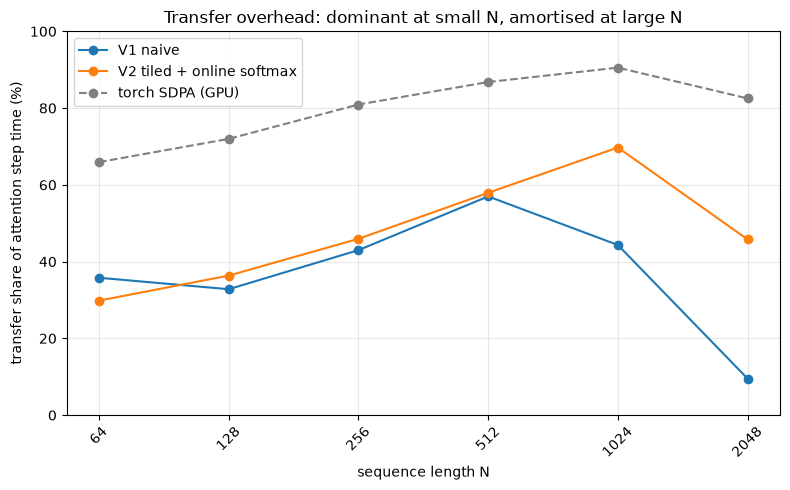

In [9]:
# Chart 2 -- transfer share of the attention step: (with transfer - kernel) / with transfer
if cuda.is_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    for name in ktimes:
        shares = [max(e - k, 0.0) / e * 100 for e, k in zip(times[name], ktimes[name])]
        ax.plot(SEQ_LENS, shares, marker="o", color=COLORS[name],
                linestyle="--" if "SDPA" in name else "-", label=name)
    ax.set_xscale("log", base=2)
    ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("transfer share of attention step time (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Transfer overhead: dominant at small N, amortised at large N")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

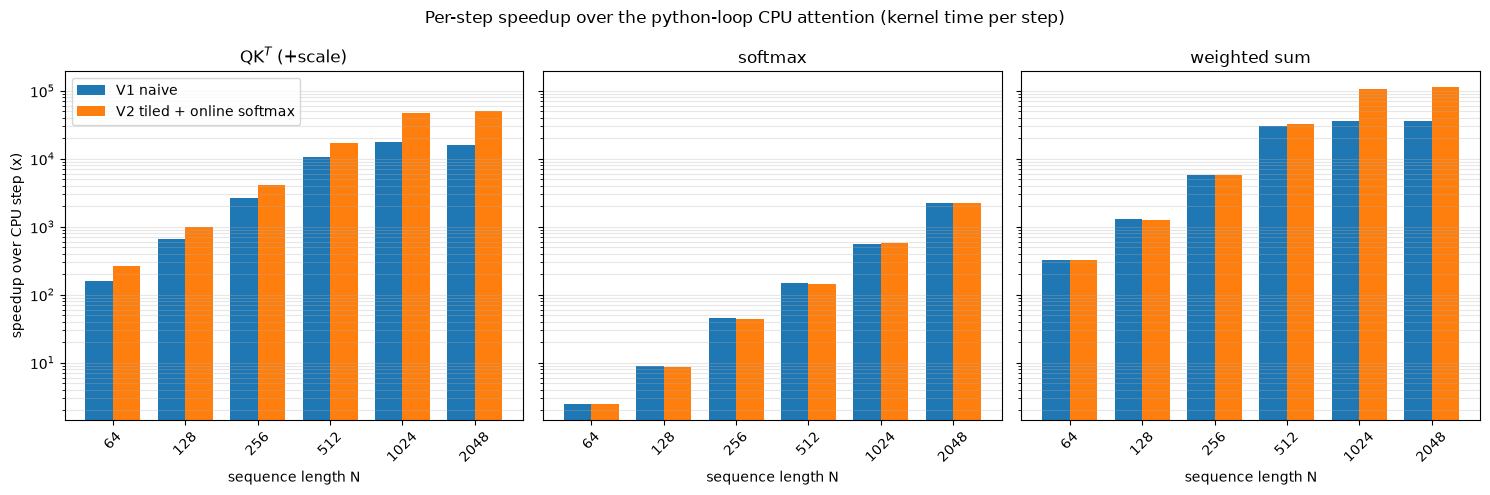

In [10]:
# Chart 3 -- per-step speedup over the CPU attention: V1 vs V2 at each N
if cuda.is_available():
    step_names = {"2a_qk_matmul": "QK$^T$ (+scale)", "2b_softmax": "softmax",
                  "2c_value_weighted_sum": "weighted sum"}
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    xpos = np.arange(len(SEQ_LENS))
    w = 0.76 / len(ksteps)
    offs = (np.arange(len(ksteps)) - (len(ksteps) - 1) / 2) * w
    for ax, (step, title) in zip(axes, step_names.items()):
        for off, (name, ks) in zip(offs, ksteps.items()):
            speedups = [c[step] / g[step] for c, g in zip(cpu_steps, ks)]
            ax.bar(xpos + off, speedups, w, color=COLORS[name], label=name)
        ax.set_yscale("log")
        ax.set_xticks(xpos, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, axis="y", which="both", alpha=0.3)
    axes[0].set_ylabel("speedup over CPU step (x)")
    axes[0].legend()
    plt.suptitle("Per-step speedup over the python-loop CPU attention (kernel time per step)")
    plt.tight_layout()
    plt.show()

## Conclusion

Chart 1 picked the target — attention is the only step whose share of the
forward pass grows with N, overtaking every linear step past
$N \approx 5.5D$ — and replacing just that step takes N = 2048 attention from
~8 min on the CPU baseline to ~11 ms with V2, transfers included (~4×10⁴×;
even naive V1 lands ~2×10⁴×). The headline number is against the deliberately
sequential python-loop baseline; the fair vectorized comparison is the torch
SDPA (GPU) column in both benchmark tables. The GPU-side tax is the pipeline
boundary, not compute: transfer overhead dominates at small N and amortises
as O(N²) compute grows (Chart 2).

The kernel ladder is a data-reuse story, and Chart 3 shows where each rung
lands step by step. V1 is coalesced but reuse-free — every matmul operand is
re-read from global memory per output element; V2's 16×16 shared-memory tiles
request ~16× fewer bytes for the same math, and its one-pass online softmax
replaces V1's three passes over the row. Together that is ~3× over V1
kernel-to-kernel. The remaining ~7× to torch SDPA is algorithmic, not tuning:
fuse the whole pipeline so the N×N matrix never exists. Fewer bytes, not
better scheduling, is the next step.